In [27]:
!pip install gensim sentence-transformers umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer


Downloads Dependencies

In [28]:
# 1. Load and clean dataset
files = glob.glob("/content/archive/csv/*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)

texts = all_df['Lyric'].dropna().tolist()[:2000]
print("Dataset size (raw):", len(texts))

Dataset size (raw): 2000


Reads all CSV files inside your dataset folder.

Drops extra columns like Unnamed: 0.

Collects all lyrics into one list.

Uses only the first 2000 lyrics to keep things manageable.

In [29]:
# Clean function
BOILERPLATE_PATTERNS = [
    r"lyrics (for this song )?have yet to be released.*",
    r"lyrics available upon release.*",
    r"stay tuned.*",
    r"check back.*",
]
META_PATTERNS = [
    r"\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\b\s+\d{1,2}",
    r"\b\d{2,4}\b",
    r"\b(las vegas|tokyo|seattle|denver|chicago|europe|north america|asia)\b",
    r"\[(?:verse|chorus|hook|bridge).*?\]",
]
boiler_re = re.compile("|".join(BOILERPLATE_PATTERNS), flags=re.I)
meta_re = re.compile("|".join(META_PATTERNS), flags=re.I)

def clean_lyric(text: str) -> str:
    txt = text.lower()
    lines = []
    for line in txt.splitlines():
        if boiler_re.search(line):
            continue
        if meta_re.search(line):
            line = meta_re.sub(" ", line)
        lines.append(line)
    txt = "\n".join(lines)
    txt = re.sub(r"\b(yeah|oh|la|na|uh|ooh|ayy)\b(?:\s+\1\b){1,}", r"\1", txt)
    txt = re.sub(r"\b(\w+)(?:\s+\1\b){2,}", r"\1 \1", txt)
    txt = re.sub(r"[^a-z'\s]", " ", txt)
    txt = re.sub(r"\s{2,}", " ", txt).strip()
    return txt

texts_clean = [clean_lyric(t) for t in texts]

This function:

Removes boilerplate text like “lyrics not yet released”.

Removes metadata like dates or city names.

Collapses repeated filler words ("yeah yeah yeah" - "yeah").

Removes special characters.

Makes everything lowercase.

In [30]:
# 2. Helper functions
def plot_clusters(X, labels, title):
    reducer = umap.UMAP(random_state=42, n_neighbors=30, min_dist=0.1)
    reduced = reducer.fit_transform(X)
    plt.figure(figsize=(7,6))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette="Set2", s=50)
    plt.title(title)
    plt.show()

def show_cluster_examples(texts_in, labels, n=3):
    for i in sorted(set(labels)):
        print(f"\n--- Cluster {i} ---")
        cluster_examples = [texts_in[j][:200] for j in range(len(texts_in)) if labels[j] == i][:n]
        for ex in cluster_examples:
            print("  •", ex, "...")

CUSTOM_STOPS = {
    "yeah","oh","la","na","uh","ooh","ayy",
    "just","like","got","let","make","know","don","ll","ain","im","gonna","cause",
    "song","lyrics","released","release","check","available","soon","stay","tuned",
}

def label_clusters_pretty(texts_in, labels, top_n=8):
    clusters = sorted(set(labels))
    cluster_docs = [" ".join([texts_in[i] for i in range(len(texts_in)) if labels[i]==c])
                    for c in clusters]

    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        max_features=8000,
        token_pattern=r"(?u)\b[a-z][a-z']+\b"
    )
    X = vectorizer.fit_transform(cluster_docs)
    terms = np.array(vectorizer.get_feature_names_out())

    mask = np.array([all(w not in CUSTOM_STOPS for w in term.split()) for term in terms])
    X = X[:, mask]
    terms = terms[mask]

    for c, row in enumerate(X.toarray()):
        top_ids = row.argsort()[::-1][:top_n]
        top_words = terms[top_ids]
        print(f"\nCluster {c} → Theme (rough): {', '.join(top_words)}")
        ex = [texts_in[i][:160] for i in range(len(texts_in)) if labels[i]==clusters[c]][:2]
        for e in ex:
            print("   •", e, "...")

Contains small tools to help later:

plot_clusters - visualize clusters in 2D using UMAP.

show_cluster_examples - print sample lyrics from each cluster.

label_clusters_pretty - find top words that describe each cluster.

Also defines a set of stopwords (common useless words like "yeah", "oh", "just").


Silhouette Score (BoW): 0.016442908881774552


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


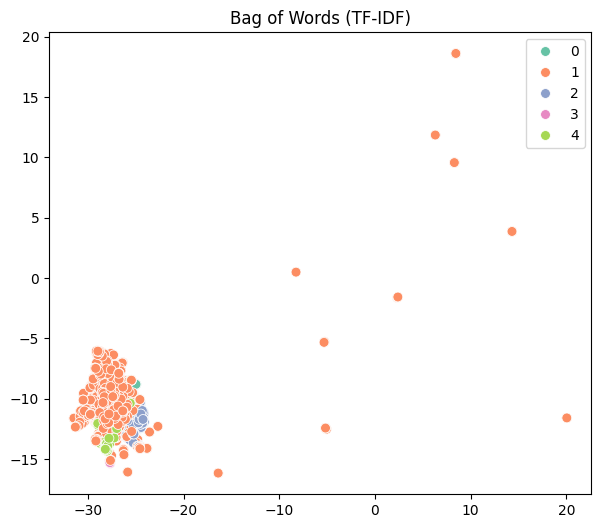


Cluster 0 → Theme (rough): charlie, charlie puth, puth, don't, talk anymore, baby, don't talk, anymore
   • charlie puth we don't talk anymore we don't talk anymore we don't talk anymore like we used to do we don't love anymore what was all of it for oh we don't talk  ...
   • charlie puth let's marvin gaye and get it on you got the healing that i want just like they say it in the song until the dawn let's marvin gaye and get it on ch ...

Cluster 1 → Theme (rough): i'm, love, don't, it's, you're, baby, wanna, want
   • cardi b al t mclaran megan thee stallion whores in this house there's some whores in this house there's some whores in this house there's some whores in this ho ...
   • cardi b look i just want to break up all your shit call your mama phone let her know that she raised a bitch then dial tone click and fuck your little fake ass  ...

Cluster 2 → Theme (rough): i'm, bitch, bitches, don't, nicki, fuck, money, shit
   • ksr it's cardi ayy said i'm the shit they can't fuck

In [31]:
# 3. Bag of Words (TF-IDF)
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))
X_bow = vectorizer.fit_transform(texts_clean)
X_bow_reduced = TruncatedSVD(n_components=100, random_state=42).fit_transform(X_bow)

kmeans_bow = KMeans(n_clusters=5, random_state=42)
labels_bow = kmeans_bow.fit_predict(X_bow_reduced)

print("\nSilhouette Score (BoW):", silhouette_score(X_bow_reduced, labels_bow))
plot_clusters(X_bow_reduced, labels_bow, "Bag of Words (TF-IDF)")
label_clusters_pretty(texts_clean, labels_bow)
show_cluster_examples(texts, labels_bow)

Turns lyrics into a word count matrix (BoW).

Reduces dimensions with SVD (to 100 features).

Runs KMeans clustering into 5 groups.

Prints silhouette score (quality of clusters).

Shows themes + example lyrics.

 BoW captures only word frequency, no meaning.


Silhouette Score (Skip-Gram): 0.11165645769424445


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


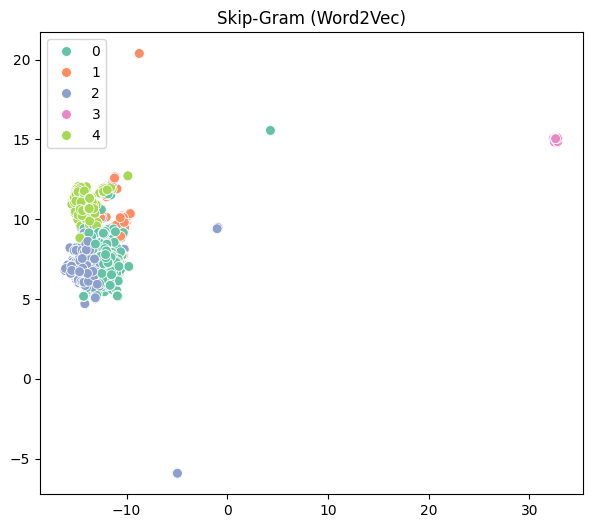


Cluster 0 → Theme (rough): i'm, don't, love, baby, wanna, you're, girl, want
   • yeah care for me care for me care for me uh yeah look i wanna get married like the currys steph and ayesha shit but we more like bellytommy and keisha shit gave ...
   • kehlani ooh ring ring kehlani you don't hit my line no more oh you don't make it ring ring i can't keep this on the low i want you to make it ring ring cardi b  ...

Cluster 1 → Theme (rough): jungkook, jimin, rm, jin, love, suga, jhope, i'm
   • alright gentleman i want you to repeat after me just how i do it ready rada da da dada dada da da your turn lada da da dada dada da da very good lada da dada da ...
   • jungkook 'cause i i'm in the stars tonight so watch me bring the fire and set the night alight jungkook shoes on get up in the morn' cup of milk let's rock and  ...

Cluster 2 → Theme (rough): i'm, love, don't, it's, time, you're, eyes, think
   • verse i'm seein' all my business while i scroll on the phone i was hopin' that we 

In [32]:
# 4. Skip-Gram (Word2Vec)
sentences = [t.split() for t in texts_clean]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

def get_song_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

X_skipgram = np.array([get_song_vector(t, w2v_model) for t in sentences])
X_skipgram_reduced = PCA(n_components=50, random_state=42).fit_transform(X_skipgram)

kmeans_skip = KMeans(n_clusters=5, random_state=42)
labels_skip = kmeans_skip.fit_predict(X_skipgram_reduced)

print("\nSilhouette Score (Skip-Gram):", silhouette_score(X_skipgram_reduced, labels_skip))
plot_clusters(X_skipgram_reduced, labels_skip, "Skip-Gram (Word2Vec)")
label_clusters_pretty(texts_clean, labels_skip)
show_cluster_examples(texts, labels_skip)

Trains a Skip-Gram Word2Vec model on your lyrics.

Each word gets a vector based on its context.

Each lyric is represented by the average of its word vectors.

PCA reduces features to 50.

Clusters with KMeans (5 groups).

Skip-Gram captures semantic relationships (e.g., "love" close to "heart").

Batches:   0%|          | 0/63 [00:00<?, ?it/s]


Silhouette Score (Pretrained Embeddings): 0.11445165


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


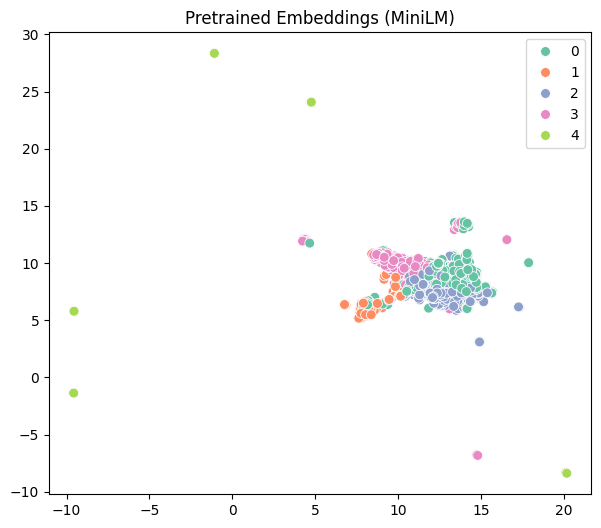


Cluster 0 → Theme (rough): i'm, love, don't, baby, you're, wanna, girl, it's
   • you know i could love you with all my heart you're my baby and and i love you i just i just feel the need to hurt you maybe i'm scorn maybe i need a therapist m ...
   • cardi b cardi josh x cardi b i see the pain in your eyes and truth is only the strong survive and you still here so from here you only gon' rise spread them win ...

Cluster 1 → Theme (rough): jungkook, jimin, rm, jin, love, i'm, suga, jhope
   • shake earthquake wheezy outta here ...
   • payola ...

Cluster 2 → Theme (rough): i'm, don't, love, it's, time, you're, say, can't
   • cardi b i gave you more than i give myself so loyal to you that i betray myself well i guess ima wither away you a snake and you chose to slither today i gave m ...
   • mother cardi sister megan thee stallion new believers in this church there's some new believers in this church there's some new believers in this church there's ...

Cluster 3 → Theme (rough): 

In [33]:
# 5. Pretrained Embeddings (MiniLM)
model = SentenceTransformer("all-MiniLM-L6-v2")
X_emb = model.encode(texts_clean, show_progress_bar=True)
X_emb_reduced = PCA(n_components=50, random_state=42).fit_transform(X_emb)

kmeans_emb = KMeans(n_clusters=5, random_state=42)
labels_emb = kmeans_emb.fit_predict(X_emb_reduced)

print("\nSilhouette Score (Pretrained Embeddings):", silhouette_score(X_emb_reduced, labels_emb))
plot_clusters(X_emb_reduced, labels_emb, "Pretrained Embeddings (MiniLM)")
label_clusters_pretty(texts_clean, labels_emb)
show_cluster_examples(texts, labels_emb)

Uses a ready-made model trained on huge datasets.

Directly converts each lyric into a meaningful vector.

PCA reduces features to 50.

KMeans clustering (5 groups).

 Captures deep meaning and context without training from scratch.

##Below codes displays:

For each method:

Prints Silhouette Score (higher = better separation).

Visualizes clusters with UMAP.

Shows top words + example lyrics for each cluster.

This lets you see how BoW vs Skip-Gram vs MiniLM perform on the same dataset.

In [34]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

In [35]:
# helpers (reuse the same cleaning stops)
CUSTOM_STOPS = {
    "yeah","oh","la","na","uh","ooh","ayy",
    "just","like","got","let","make","know","don","ll","ain","im","gonna","cause",
    "song","lyrics","released","release","check","available","soon","stay","tuned",
}

# (Optional) names to downweight in titles so themes aren't just artist names
NAME_STOPS = {"charlie","puth","justin","bieber","cardi","nicki","minaj","jungkook","jimin","rm","jin","suga","jhope","bts"}


In [36]:
def cluster_top_terms(texts, labels, top_n=8, ngram_range=(1,2), remove_names_for_title=True):
    clusters = sorted(set(labels))
    cluster_docs = [" ".join([texts[i] for i in range(len(texts)) if labels[i]==c]) for c in clusters]

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        max_features=12000,
        token_pattern=r"(?u)\b[a-z][a-z']+\b"
    )
    X = vec.fit_transform(cluster_docs)
    terms = np.array(vec.get_feature_names_out())

    # filter custom stops
    mask = np.array([all(w not in CUSTOM_STOPS for w in term.split()) for term in terms])
    terms = terms[mask]
    X = X[:, mask]

    # get top terms per cluster
    top = []
    for r in X.toarray():
        idx = r.argsort()[::-1]
        words = terms[idx][:top_n].tolist()
        top.append(words)

    # derive human-friendly titles
    titles = []
    for words in top:
        # optionally downweight artist names for the title
        filtered = [w for w in words if all(tok not in NAME_STOPS for tok in w.split())] if remove_names_for_title else words
        # simple title: join first 3 non-name terms, fallback to original
        title_terms = (filtered[:3] or words[:3])
        # small beautify
        title = ", ".join(title_terms).replace(" ,", ",").title()
        titles.append(title)

    return top, titles

In [37]:
def example_snippets(texts, labels, cluster_id, n=2, max_chars=140):
    ex = [texts[i][:max_chars].replace("\n"," ") for i in range(len(texts)) if labels[i]==cluster_id][:n]
    return ex

In [38]:
def method_summary(method_name, X_reduced, labels, texts, top_n=6):
    score = float(silhouette_score(X_reduced, labels))
    top_terms, titles = cluster_top_terms(texts, labels, top_n=top_n)
    rows = []
    for cid, (words, title) in enumerate(zip(top_terms, titles)):
        rows.append({
            "Method": method_name,
            "Cluster": cid,
            "Auto Title": title,
            "Top Terms": ", ".join(words[:top_n]),
            "Examples": " | ".join(example_snippets(texts, labels, cid))
        })
    return score, pd.DataFrame(rows)

In [39]:
# build summaries
bow_score, bow_df     = method_summary("BoW (TF-IDF)", X_bow_reduced,        labels_bow,  texts_clean)
sg_score, sg_df       = method_summary("Skip-Gram (Word2Vec)", X_skipgram_reduced, labels_skip, texts_clean)
emb_score, emb_df     = method_summary("Pretrained (MiniLM)", X_emb_reduced, labels_emb, texts_clean)

summary_scores = pd.DataFrame([
    {"Method": "BoW (TF-IDF)",        "Silhouette": round(bow_score, 3)},
    {"Method": "Skip-Gram (Word2Vec)","Silhouette": round(sg_score, 3)},
    {"Method": "Pretrained (MiniLM)", "Silhouette": round(emb_score, 3)},
])

In [40]:
# display
print("=== Silhouette Scores ===")
print(summary_scores.to_string(index=False))

=== Silhouette Scores ===
              Method  Silhouette
        BoW (TF-IDF)       0.016
Skip-Gram (Word2Vec)       0.112
 Pretrained (MiniLM)       0.114


In [41]:
print("\n=== Cluster Titles & Examples: BoW (TF-IDF) ===")
display(bow_df)

print("\n=== Cluster Titles & Examples: Skip-Gram (Word2Vec) ===")
display(sg_df)

print("\n=== Cluster Titles & Examples: Pretrained (MiniLM) ===")
display(emb_df)


=== Cluster Titles & Examples: BoW (TF-IDF) ===


,Method,Cluster,Auto Title,Top Terms,Examples
0,BoW (TF-IDF),0,"Don'T, Talk Anymore, Baby","charlie, charlie puth, puth, don't, talk anymo...",charlie puth we don't talk anymore we don't ta...
1,BoW (TF-IDF),1,"I'M, Love, Don'T","i'm, love, don't, it's, you're, baby",cardi b al t mclaran megan thee stallion whore...
2,BoW (TF-IDF),2,"I'M, Bitch, Bitches","i'm, bitch, bitches, don't, nicki, fuck",ksr it's cardi ayy said i'm the shit they can'...
3,BoW (TF-IDF),3,"Christmas, Merry, Baby","christmas, merry, baby, christmas christmas, m...",my winter nights are taken up by static stress...
4,BoW (TF-IDF),4,"I'M, Baby, Girl","bieber, justin, justin bieber, i'm, baby, girl",justin bieber oh whoa oh whoa oh whoa justin b...



=== Cluster Titles & Examples: Skip-Gram (Word2Vec) ===


,Method,Cluster,Auto Title,Top Terms,Examples
0,Skip-Gram (Word2Vec),0,"I'M, Don'T, Love","i'm, don't, love, baby, wanna, you're",yeah care for me care for me care for me uh ye...
1,Skip-Gram (Word2Vec),1,Love,"jungkook, jimin, rm, jin, love, suga",alright gentleman i want you to repeat after m...
2,Skip-Gram (Word2Vec),2,"I'M, Love, Don'T","i'm, love, don't, it's, time, you're",verse i'm seein' all my business while i scrol...
3,Skip-Gram (Word2Vec),3,"Usa, Usa Th, Th","usa, usa th, th, che, california usa, non",| payola
4,Skip-Gram (Word2Vec),4,"I'M, Don'T, Bitch","i'm, don't, bitch, bitches, ain't, it's",cardi b al t mclaran megan thee stallion whore...



=== Cluster Titles & Examples: Pretrained (MiniLM) ===


,Method,Cluster,Auto Title,Top Terms,Examples
0,Pretrained (MiniLM),0,"I'M, Love, Don'T","i'm, love, don't, baby, you're, wanna",you know i could love you with all my heart yo...
1,Pretrained (MiniLM),1,"Love, I'M","jungkook, jimin, rm, jin, love, i'm",shake earthquake wheezy outta here | payola
2,Pretrained (MiniLM),2,"I'M, Don'T, Love","i'm, don't, love, it's, time, you're",cardi b i gave you more than i give myself so ...
3,Pretrained (MiniLM),3,"I'M, Don'T, Bitch","i'm, don't, bitch, bitches, it's, ain't",cardi b al t mclaran megan thee stallion whore...
4,Pretrained (MiniLM),4,"Zutto, Good Wave, Goodness","zutto, good wave, goodness, goodbyes, goodbye ...",|


# What's Really Happening in the Models

We are trying 3 different ways to turn lyrics (which are just words) into numbers so that a computer can group similar songs together.

Think of it like teaching a computer how to understand music themes without ever hearing the actual songs.

---

## 1. Bag of Words (BoW)

Imagine each lyric as a shopping list.

"love, baby, heart, forever" - love:1, baby:1, heart:1, forever:1

"money, car, party, baby" - money:1, car:1, party:1, baby:1

The computer just counts words.

If two songs use a lot of the same words (like "baby"), they look similar.

But it doesn’t know meaning.

"heart" and "love" might appear in different lists, and BoW can’t tell they are related.

So clustering here is like:  
- "All songs that keep saying 'baby' go together"  
- "All songs that say 'Christmas' go together"  

---

## 2. Skip-Gram (Word2Vec)

Here we teach the computer that words that appear together often have similar meaning.

For example:

- In love songs, "heart" often appears near "love", "forever", "baby".  
- In rap, "money" appears near "cash", "bitch", "flex".  

The skip-gram model learns these relationships.

- "heart" and "love" - close in vector space.  
- "money" and "cash" - close in vector space.  

Then for a whole lyric, we average the word meanings - so a love song will look different from a party song.

So clustering here is like:  
- "Love songs (heart, baby, forever)"  
- "Party/rap songs (money, cash, flex)"  
- "Holiday songs (Christmas, snow, gifts)"  

This is smarter than BoW because it cares about context, not just counts.

---

## 3. Pretrained Embeddings (MiniLM)

Imagine borrowing the brain of a model that has already read millions of texts.

It already knows that "sad" and "cry" are related, even if they don’t appear in your dataset.

It knows "Christmas" is related to "holiday" because it has seen them used in books, articles, and websites.

So when you give it a lyric, it transforms the whole sentence into a meaningful vector — almost like a summary of the emotion and topic.

Clustering here is like:  
- "Sad breakup songs"  
- "Love/romantic songs"  
- "Rap/party hype songs"  
- "Holiday songs"  

This is the most powerful method because it doesn’t just learn from your dataset, it brings in knowledge from the entire internet.
